#Juan David Loaiza Agudelo
#Tatiana Gallo

In [2]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


1. Construcción de Señales Periódica

Se definen dos señales periódicas en el tiempo: una onda cuadrada y una onda triangular, ambas con las siguientes especificaciones:

---Frecuencia fundamental ($f_0$): $5\text{ Hz}$

---Período $T_0 = 0.2\text{ s}$

---Amplitud ($A$): $1.0$

---Frecuencia de muestreo ($f_s$): $1000\text{ Hz}$

---Número de muestras por período ($N$): $N = \frac{f_s}{f_0} = 200\text{ muestras}$

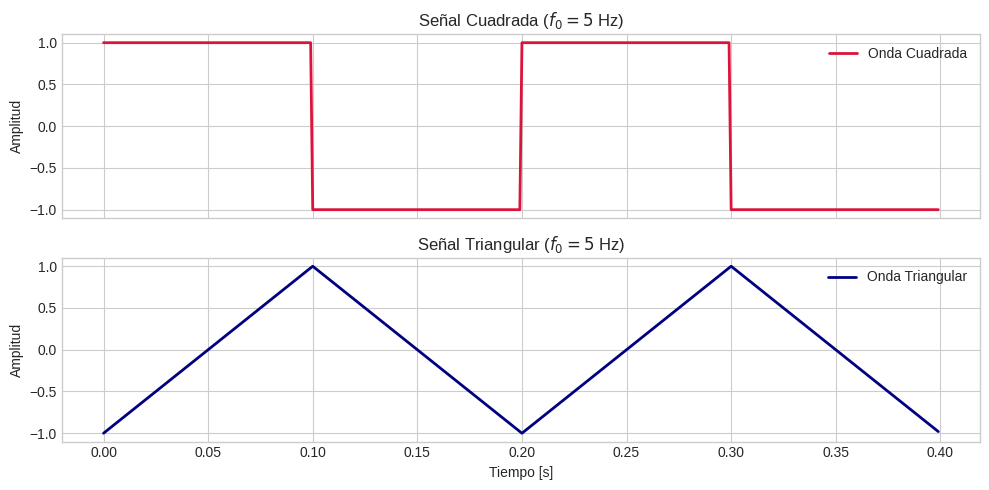

In [3]:
# Parametros del sistema
f0 = 5.0             # Frecuencia fundamental (Hz)
T0 = 1.0 / f0        # Período (s)
A = 1.0              # Amplitud de la señal
fs = 1000.0          # Frecuencia de muestreo (Hz)
num_periodos = 2     # Número de períodos a visualizar
t = np.arange(0, num_periodos * T0, 1.0 / fs) # Vector de tiempo
N_periodo = int(fs * T0) # Muestras contenidas en 1 período (200 muestras)

# a) Señal cuadrada periódica
x_cuadrada = A * signal.square(2 * np.pi * f0 * t)

# b) Señal triangular periódica (onda simétrica con width=0.5)
x_triangular = A * signal.sawtooth(2 * np.pi * f0 * t, width=0.5)

# c) Graficación de ambas señales en el dominio del tiempo
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

axes[0].plot(t, x_cuadrada, color='crimson', lw=2, label='Onda Cuadrada')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Señal Cuadrada ($f_0 = 5$ Hz)')
axes[0].grid(True)
axes[0].legend(loc='upper right')

axes[1].plot(t, x_triangular, color='navy', lw=2, label='Onda Triangular')
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylabel('Amplitud')
axes[1].set_title('Señal Triangular ($f_0 = 5$ Hz)')
axes[1].grid(True)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

2. Cálculo de los Coeficientes de la Serie de Fourier Exponencial para una señal continua periódica $x(t)$, los coeficientes complejos $c_k$ de la serie exponencial de Fourier vienen dados por:$$c_k = \frac{1}{T_0} \int_{0}^{T_0} x(t) e^{-j 2\pi k f_0 t} \, dt$$En el entorno discreto computacional, se aproxima la integral evaluando $N$ muestras en un período mediante la Transformada Discreta de Fourier (DFT/FFT):$$c_k = \frac{1}{N} \sum_{n=0}^{N-1} x[n] e^{-j \frac{2\pi k n}{N}}$$

In [5]:
# d) Funcion para calcular los coeficientes de Fourier exponenciales
def calcular_coeficientes_fourier(x, N_per):

    x_un_periodo = x[:N_per]
    # np.fft.fft calcula sum(x[n]*exp(-j*2*pi*k*n/N)), escalamos por 1/N
    ck = np.fft.fft(x_un_periodo) / N_per
    return ck

# e) Aplicacion a las señales cuadrada y triangular
ck_cuadrada = calcular_coeficientes_fourier(x_cuadrada, N_periodo)
ck_triangular = calcular_coeficientes_fourier(x_triangular, N_periodo)

print(f"Coeficientes calculados correctamente.")
print(f"Número total de coeficientes obtenidos por período: {len(ck_cuadrada)}")
print(f"Componente DC (c_0) Onda Cuadrada: {np.real(ck_cuadrada[0]):.4f}")
print(f"Componente DC (c_0) Onda Triangular: {np.real(ck_triangular[0]):.4f}")

Coeficientes calculados correctamente.
Número total de coeficientes obtenidos por período: 200
Componente DC (c_0) Onda Cuadrada: 0.0000
Componente DC (c_0) Onda Triangular: -0.0000


3. Espectros de Magnitud y Fase. El espectro de magnitud $\vert{}c_k\vert{}$ representa la distribución de amplitud por componente armónico, mientras que el espectro de fase $\arg(c_k)$ representa el ángulo de desfase asociado a cada frecuencia

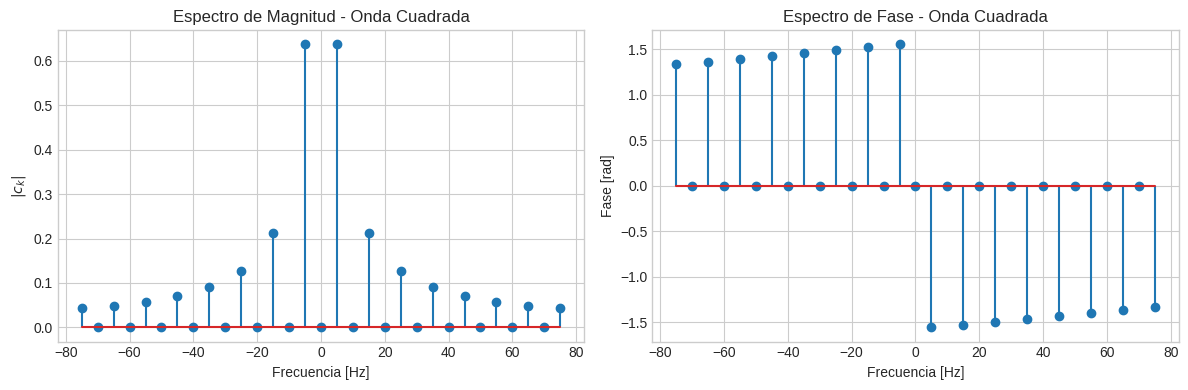

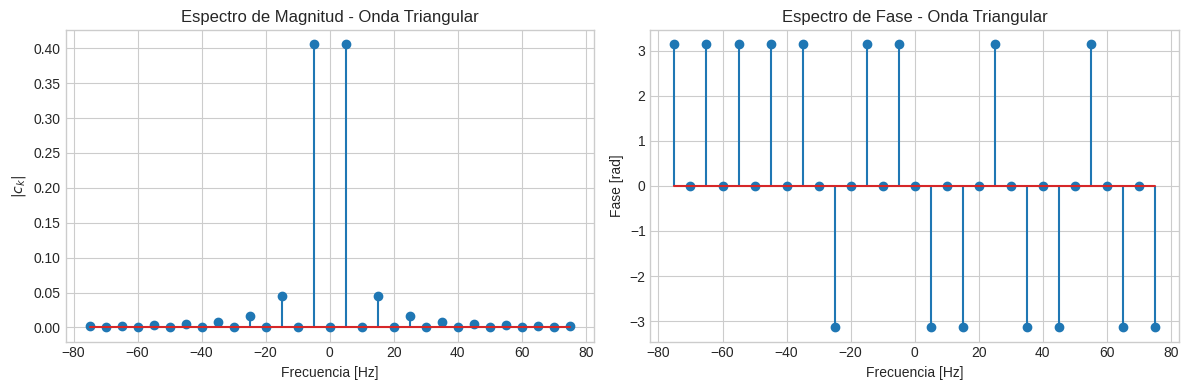

In [6]:
# f) Funcion para graficar el espectro de magnitud y fase
def graficar_espectro(ck, fs, f0, titulo_senal, num_armonicos=15):
    N = len(ck)
    freqs = np.fft.fftfreq(N, d=1.0/fs)

    # Desplazamiento para poner la frecuencia 0 Hz
    ck_shift = np.fft.fftshift(ck)
    freqs_shift = np.fft.fftshift(freqs)

    magnitud = np.abs(ck_shift)
    fase = np.angle(ck_shift)

    # Elimina el ruido de fase donde la magnitud sea despreciable
    fase[magnitud < 1e-4] = 0.0

    # Filtra el rango visual alrededor de los armonicos principales
    limite_freq = num_armonicos * f0
    mask = (freqs_shift >= -limite_freq) & (freqs_shift <= limite_freq)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Espectro de magnitud
    axes[0].stem(freqs_shift[mask], magnitud[mask])
    axes[0].set_title(f'Espectro de Magnitud - {titulo_senal}')
    axes[0].set_xlabel('Frecuencia [Hz]')
    axes[0].set_ylabel('$|c_k|$')
    axes[0].grid(True)

    # Espectro de fase
    axes[1].stem(freqs_shift[mask], fase[mask])
    axes[1].set_title(f'Espectro de Fase - {titulo_senal}')
    axes[1].set_xlabel('Frecuencia [Hz]')
    axes[1].set_ylabel('Fase [rad]')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# g) Graficacion para la señal cuadrada y la señal triangular
graficar_espectro(ck_cuadrada, fs, f0, 'Onda Cuadrada')
graficar_espectro(ck_triangular, fs, f0, 'Onda Triangular')

4. Reconstrucción de señales mediante suma de armonicos. La síntesis o reconstrucción de una señal truncada a un número $K$ de armónicos se define mediante la ecuación exponencial:$$x[n] \approx \sum_{k=-K}^{K} c_k e^{j \frac{2\pi k n}{N}}$$Aprovechando la simetría para señales reales ($c_{-k} = c_k^*$), se expresa equivalente como:$$x(t) \approx c_0 + 2 \sum_{k=1}^{K} \text{Re} \left( c_k e^{j 2\pi k f_0 t} \right)$$

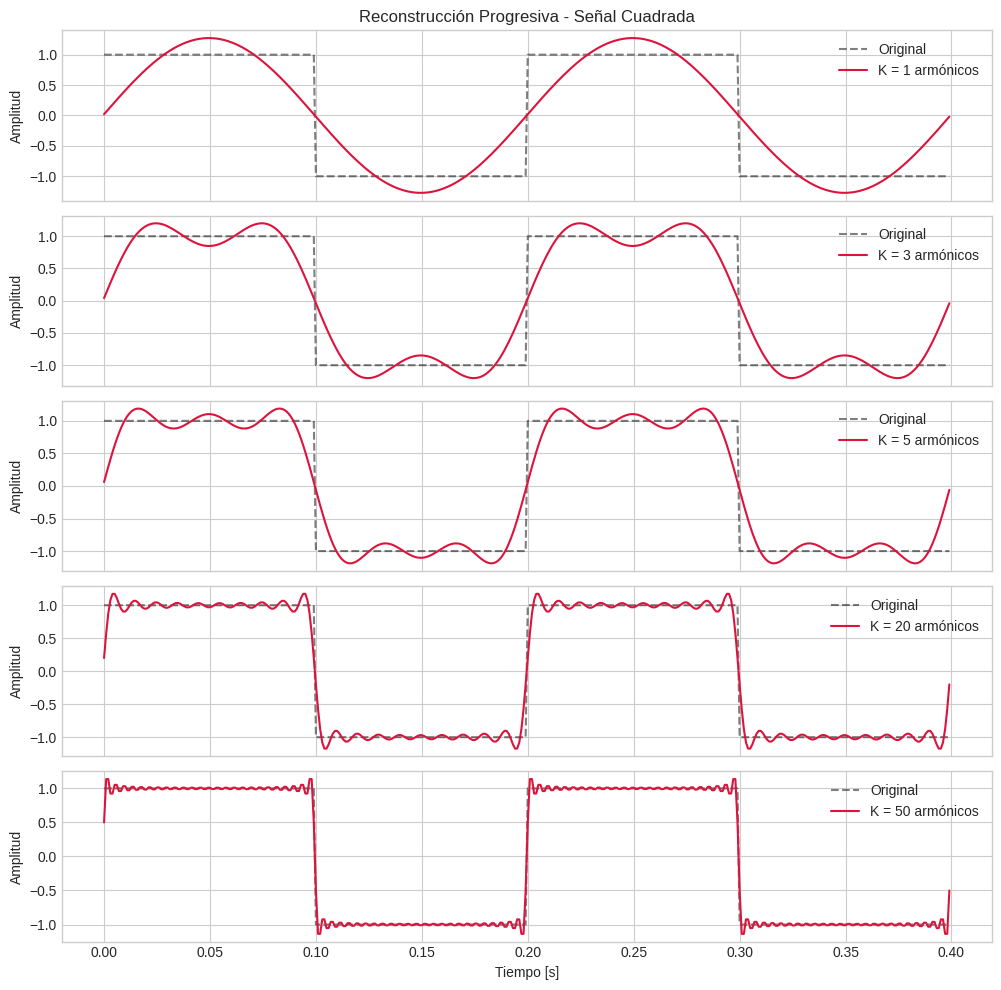

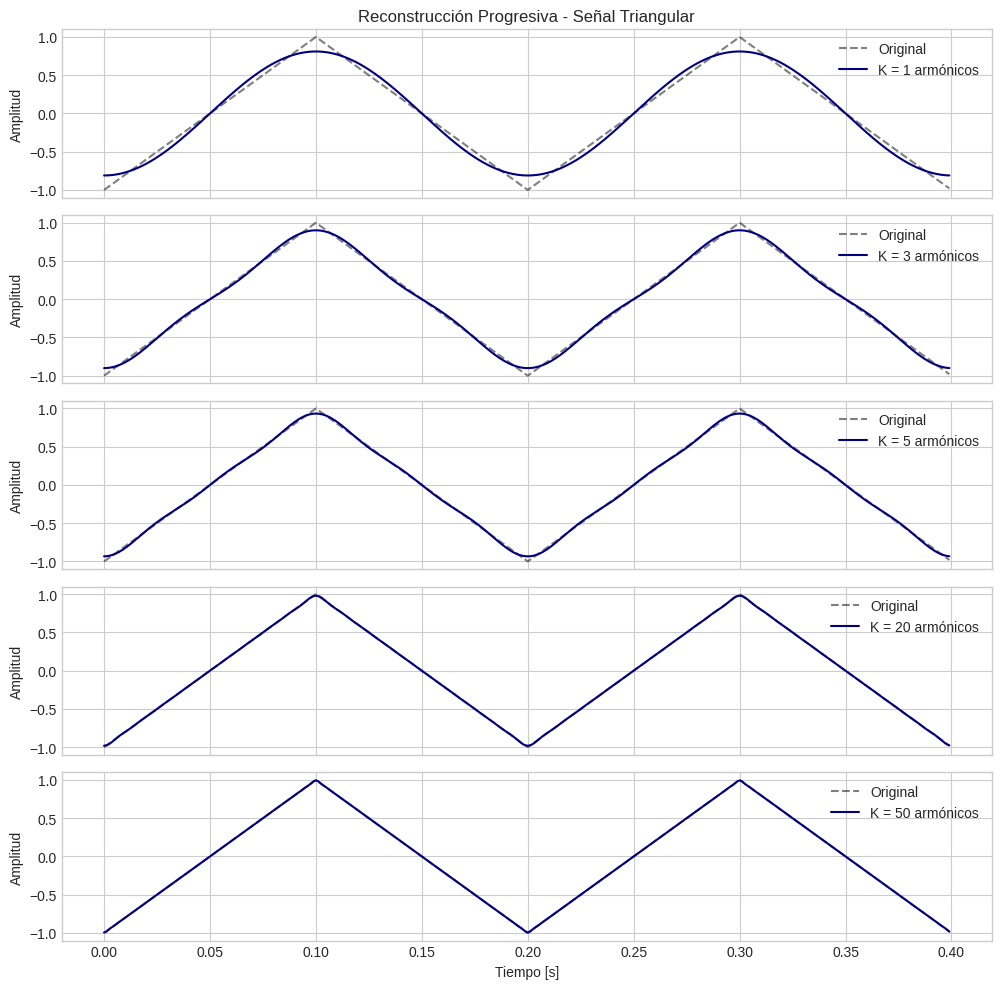

In [7]:
# Funcion de reconstruccion paso a paso a partir de K armónicos
def reconstruir_senal(ck, K, t, f0):
    N = len(ck)
    x_rec = np.real(ck[0]) * np.ones_like(t) # Componente DC

    for k in range(1, K + 1):
        if k < N // 2:
            # 2 * Re(c_k * e^(j*2*pi*k*f0*t))
            armonico = 2.0 * np.real(ck[k] * np.exp(1j * 2 * np.pi * k * f0 * t))
            x_rec += armonico

    return x_rec

#Reconstruccion con N_armonicos = [1, 3, 5, 20, 50]
armonicos_evaluar = [1, 3, 5, 20, 50]

#Grafica para la Señal Cuadrada
fig, axes = plt.subplots(len(armonicos_evaluar), 1, figsize=(10, 10), sharex=True)
for idx, K in enumerate(armonicos_evaluar):
    rec_sq = reconstruir_senal(ck_cuadrada, K, t, f0)
    axes[idx].plot(t, x_cuadrada, 'k--', alpha=0.5, label='Original')
    axes[idx].plot(t, rec_sq, color='crimson', lw=1.5, label=f'K = {K} armónicos')
    axes[idx].set_ylabel('Amplitud')
    axes[idx].grid(True)
    axes[idx].legend(loc='upper right')
axes[0].set_title('Reconstrucción Progresiva - Señal Cuadrada')
axes[-1].set_xlabel('Tiempo [s]')
plt.tight_layout()
plt.show()

#Grafica para la Señal Triangular
fig, axes = plt.subplots(len(armonicos_evaluar), 1, figsize=(10, 10), sharex=True)
for idx, K in enumerate(armonicos_evaluar):
    rec_tri = reconstruir_senal(ck_triangular, K, t, f0)
    axes[idx].plot(t, x_triangular, 'k--', alpha=0.5, label='Original')
    axes[idx].plot(t, rec_tri, color='navy', lw=1.5, label=f'K = {K} armónicos')
    axes[idx].set_ylabel('Amplitud')
    axes[idx].grid(True)
    axes[idx].legend(loc='upper right')
axes[0].set_title('Reconstrucción Progresiva - Señal Triangular')
axes[-1].set_xlabel('Tiempo [s]')
plt.tight_layout()
plt.show()

5. Análisis del Fenómeno de Gibbs.

Definicion: El Fenómeno de Gibbs describe el comportamiento anómalo que presenta la serie de Fourier cuando se aproxima una señal periódica que posee discontinuidades de salto (como la onda cuadrada) utilizando un número finito de armónicos

 Interpretacion:Alrededor de los puntos de discontinuidad se generan oscilaciones conocidas ondulaciones.Se presenta un sobrepico persistente cuya amplitud máxima no tiende a cero cuando $K \to \infty$.Matemáticamente, la amplitud de este sobrepico se estabiliza en aproximadamente el $8.95\%$ (casi $9\%$) del valor total del salto de la discontinuidad, independientemente del número de armónicos agregados.

 Diferencia entre Señal Cuadrada y Triangular:


Señal Cuadrada: Es discontinua en el tiempo. Sus coeficientes caen con una tasa de orden (1/k), produciendo un fenómeno de Gibbs pronunciado que concentra la oscilación en una franja cada vez más estrecha alrededor del salto conforme $K$ aumenta.

Señal Triangular: Es una función continua a trozos (solo su derivada es discontinua). Sus coeficientes decaen con mayor rapidez, a una tasa de (1/k^2). Por lo tanto, no presenta fenómeno de Gibbs en la reconstrucción y converge de forma uniforme y suave hacia la señal original.

6. Composición Espectral de una Señal ECG e Interpretación Fisiológica. El electrocardiograma (ECG) mide los cambios de potencial eléctrico generados durante el ciclo cardíaco. Sus ondas principales comprenden componentes espectrales bien diferenciados:

Onda P (Despolarización Auricular):Es una onda de variación lenta y amplitud baja ($< 0.25\text{ mV}$).

Rango espectral: Se concentra en baja frecuencia, principalmente de $0.5\text{ Hz}$ a $10\text{ Hz}$ (pico en alrededor de $1 - 3\text{ Hz}$).

Complejo QRS (Despolarización Ventricular):Representa la transición más rápida y abrupta del ECG (alta pendiente temporal $\frac{dv}{dt}$).

Rango espectral: Contiene las frecuencias más elevadas de la señal ECG limpia, concentrándose entre $8\text{ Hz}$ y $25\text{ Hz}$, extendiéndose hasta $40\text{ Hz}$.

Onda T (Repolarización Ventricular):Es una deflexión más ancha y suave que el complejo QRS.

Rango espectral: Dominado por componentes muy lentas entre $0.5\text{ Hz}$ y $8\text{ Hz}$.

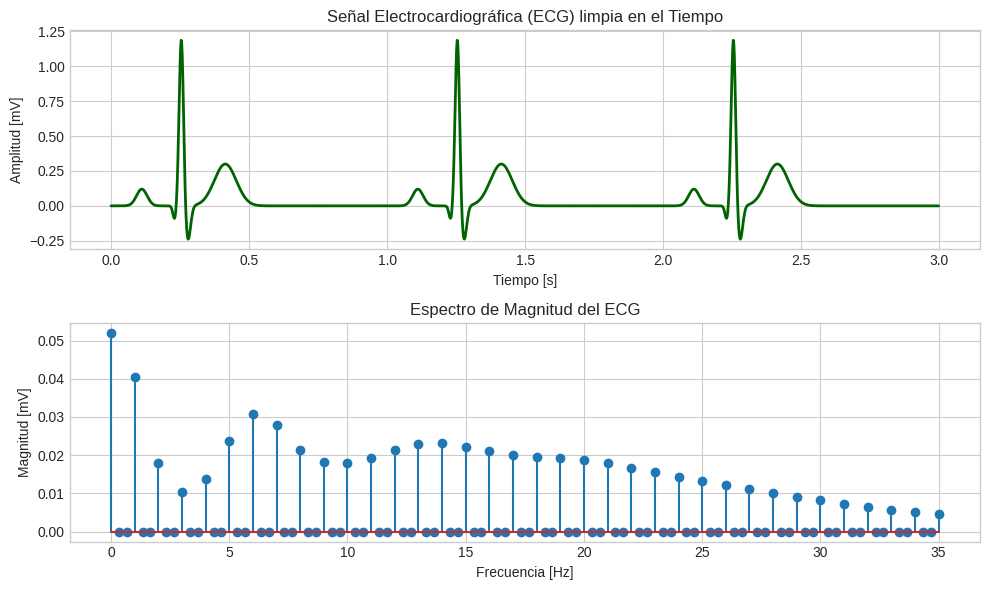

In [8]:
# k) Generacion y analisis espectral de una señal ECG sintética limpia

def generar_ecg_sintetico(t, fc_bpm=60):
    T_beat = 60.0 / fc_bpm
    fase = (2 * np.pi * t / T_beat) % (2 * np.pi)

    # Parámetros gaussianos: (Amplitud [mV], Centro [rad], Ancho sigma)
    componentes = [
        (0.12, 0.7, 0.12),   # Onda P
        (-0.10, 1.45, 0.04), # Onda Q
        (1.20, 1.60, 0.05),  # Onda R
        (-0.25, 1.75, 0.06), # Onda S
        (0.30, 2.60, 0.25)   # Onda T
    ]

    ecg = np.zeros_like(t)
    for amp, centro, ancho in componentes:
        ecg += amp * np.exp(-((fase - centro)**2) / (2 * ancho**2))
    return ecg

# Definir tiempo para 3 segundos de registro a 500 Hz
fs_ecg = 500.0
t_ecg = np.arange(0, 3.0, 1.0 / fs_ecg)
ecg_clean = generar_ecg_sintetico(t_ecg, fc_bpm=60)

# Cálculo de la FFT para obtener el espectro de magnitud del ECG
N_ecg = len(ecg_clean)
ck_ecg = np.fft.fft(ecg_clean) / N_ecg
freqs_ecg = np.fft.fftfreq(N_ecg, d=1.0/fs_ecg)

# Graficar la señal ECG y su Espectro
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Dominio del tiempo
axes[0].plot(t_ecg, ecg_clean, color='darkgreen', lw=2)
axes[0].set_title('Señal Electrocardiográfica (ECG) limpia en el Tiempo')
axes[0].set_xlabel('Tiempo [s]')
axes[0].set_ylabel('Amplitud [mV]')
axes[0].grid(True)

# Dominio de la frecuencia (Espectro de Magnitud)
mask_ecg = (freqs_ecg >= 0) & (freqs_ecg <= 35) # Filtro visual hasta 35 Hz
axes[1].stem(freqs_ecg[mask_ecg], np.abs(ck_ecg)[mask_ecg])
axes[1].set_title('Espectro de Magnitud del ECG')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].set_ylabel('Magnitud [mV]')
axes[1].grid(True)

plt.tight_layout()
plt.show()